## 1. Imports e Carregamento dos Splits


In [1]:
import pandas as pd
import joblib
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Carregando splits físicos...")
df_train = pd.read_csv('../../data/splits/train.csv')
df_val   = pd.read_csv('../../data/splits/val.csv')
df_test  = pd.read_csv('../../data/splits/test.csv')

X_train, y_train_raw = df_train.drop('classe', axis=1), df_train['classe']
X_val,   y_val_raw   = df_val.drop('classe', axis=1),   df_val['classe']
X_test,  y_test_raw  = df_test.drop('classe', axis=1),  df_test['classe']

# LabelEncoder ajustado SÓ no treino para evitar data leakage
le = LabelEncoder().fit(y_train_raw)
y_train = le.transform(y_train_raw)
y_val   = le.transform(y_val_raw)
y_test  = le.transform(y_test_raw)

print(f"Treino:    {len(X_train):4d} amostras")
print(f"Validação: {len(X_val):4d} amostras")
print(f"Teste:     {len(X_test):4d} amostras")
print(f"\nClasses: {list(le.classes_)}")


Carregando splits físicos...
Treino:    1119 amostras
Validação:  241 amostras
Teste:      240 amostras

Classes: ['Empate', 'O venceu', 'Tem jogo', 'X venceu']


## 2. Treinamento do MLP


In [7]:
print("Treinando a Rede Neural (MLP)...")
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 64),  # 1ª camada com 64 neurônios, 2ª com 32
    activation='relu',            # Função de ativação não-linear
    solver='adam',                # Otimizador rápido e eficiente
    max_iter=1000,
    random_state=42,
)
mlp.fit(X_train, y_train)
print("Treinamento concluído.")


Treinando a Rede Neural (MLP)...
Treinamento concluído.


## 3. Avaliação no Conjunto de Validação


=== VALIDAÇÃO ===
              precision    recall  f1-score   support

      Empate       0.50      0.20      0.29         5
    O venceu       0.89      1.00      0.94        48
    Tem jogo       0.95      0.86      0.91        94
    X venceu       0.94      1.00      0.97        94

    accuracy                           0.93       241
   macro avg       0.82      0.77      0.78       241
weighted avg       0.93      0.93      0.92       241



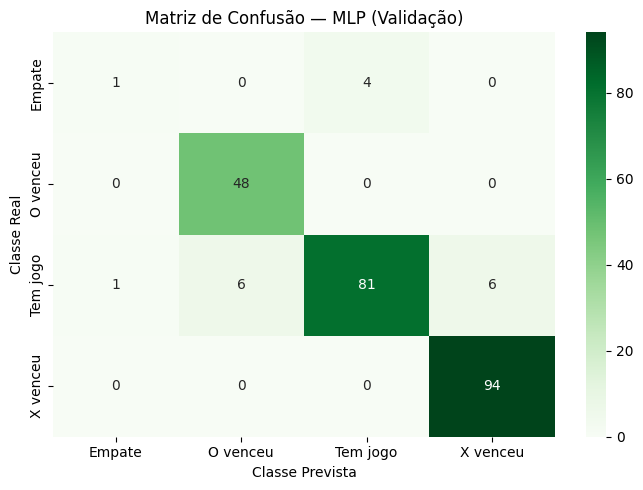

In [8]:
y_val_pred = mlp.predict(X_val)

print("=== VALIDAÇÃO ===")
print(classification_report(
    le.inverse_transform(y_val),
    le.inverse_transform(y_val_pred),
    zero_division=0,
))

plt.figure(figsize=(7, 5))
cm_val = confusion_matrix(le.inverse_transform(y_val), le.inverse_transform(y_val_pred), labels=le.classes_)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão — MLP (Validação)')
plt.ylabel('Classe Real'); plt.xlabel('Classe Prevista')
plt.tight_layout(); plt.show()


## 4. Avaliação Final no Conjunto de Teste


=== TESTE ===
              precision    recall  f1-score   support

      Empate       0.50      0.20      0.29         5
    O venceu       0.88      0.98      0.93        47
    Tem jogo       0.93      0.89      0.91        94
    X venceu       0.97      0.99      0.98        94

    accuracy                           0.93       240
   macro avg       0.82      0.77      0.78       240
weighted avg       0.93      0.93      0.93       240



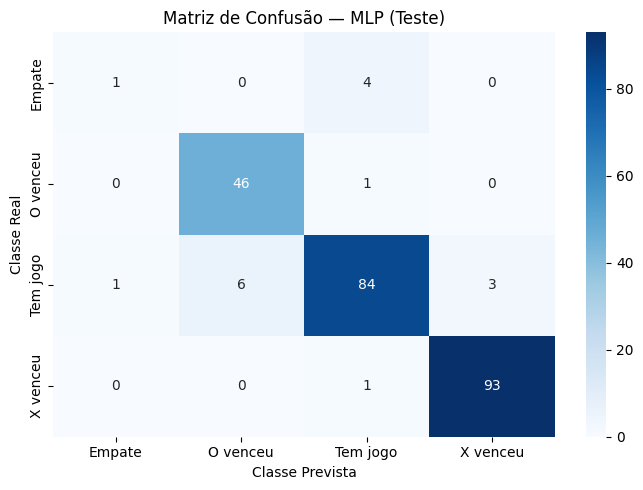

In [9]:
y_test_pred = mlp.predict(X_test)

print("=== TESTE ===")
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_test_pred),
    zero_division=0,
))

plt.figure(figsize=(7, 5))
cm_test = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_test_pred), labels=le.classes_)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão — MLP (Teste)')
plt.ylabel('Classe Real'); plt.xlabel('Classe Prevista')
plt.tight_layout(); plt.show()


## 5. Persistência do Modelo


In [ ]:
import os
os.makedirs('../../models/MLP', exist_ok=True)
joblib.dump(mlp, '../../models/MLP/mlp_model.pkl')
joblib.dump(le,  '../../models/MLP/mlp_label_encoder.pkl')
print("Modelo e Encoder salvos com sucesso!")
